In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
P_Do=pd.read_csv('disease_outbreak.csv')
P_Do.head(2)

,disease,region,week_start_date,reported_cases,hospitalizations,deaths
0,Influenza A,Northeast,2024-01-01,95,9,0
1,Influenza A,Northeast,2024-01-08,93,2,0


In [3]:
P_Do.isnull().sum()

disease             0
region              0
week_start_date     0
reported_cases      0
hospitalizations    0
deaths              0
dtype: int64

In [4]:
P_Do['deaths'].unique()

array([0, 1, 2, 3, 4, 5, 6, 7])

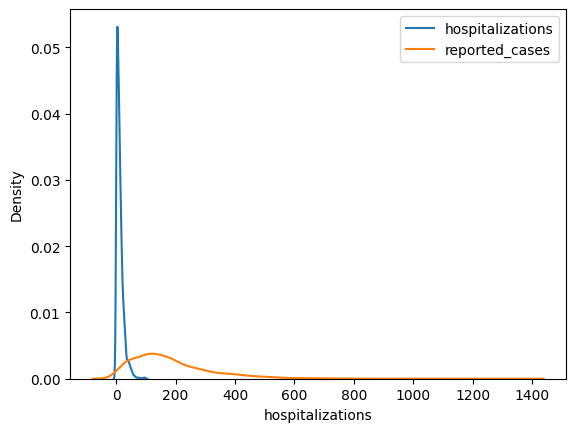

In [5]:
sns.kdeplot(P_Do['hospitalizations'], label='hospitalizations')
sns.kdeplot(P_Do['reported_cases'], label='reported_cases')
plt.legend()

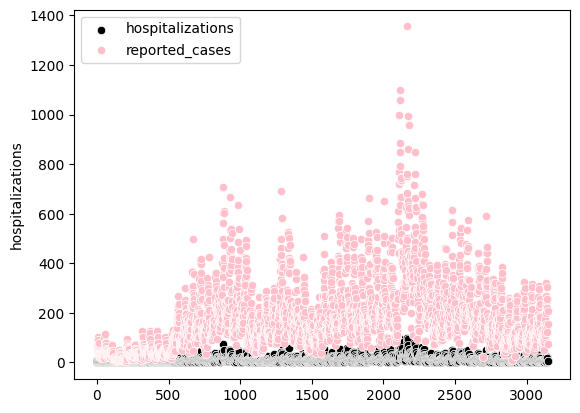

In [7]:
sns.scatterplot(P_Do['hospitalizations'], label='hospitalizations', color='black')
sns.scatterplot(P_Do['reported_cases'], label='reported_cases', color='pink')
plt.legend()

In [8]:
X3=P_Do[['hospitalizations', 'reported_cases']]
X3

,hospitalizations,reported_cases
0,9,95
1,2,93
2,2,73
3,7,67
4,3,101
...,...,...
3145,11,124
3146,19,220
3147,6,208
3148,6,154


In [9]:
Y3=P_Do['deaths']
Y3

0       0
1       0
2       0
3       0
4       0
       ..
3145    0
3146    1
3147    0
3148    0
3149    0
Name: deaths, Length: 3150, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split

X3_train, X3_test, Y3_train, Y3_test = train_test_split(X3, Y3, test_size=0.20)
X3_train.shape, X3_test.shape

((2520, 2), (630, 2))

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()


# fit the scaler to the train set, it will learn the parameters

scaler.fit(X3_train)

# transform train and test sets
X3_train_scaled=scaler.transform(X3_train)
X3_test_scaled=scaler.transform(X3_test)

In [13]:
X3_train_scaled_df=pd.DataFrame(X3_train_scaled, columns=X3_train.columns)
X3_test_scaled_df=pd.DataFrame(X3_test_scaled, columns=X3_test.columns)

In [14]:
np.round(X3_train.describe(), 1)

,hospitalizations,reported_cases
count,2520.0,2520.0
mean,12.6,186.0
std,11.9,140.6
min,0.0,4.0
25%,4.0,92.0
50%,9.0,155.0
75%,17.0,248.0
max,98.0,1355.0


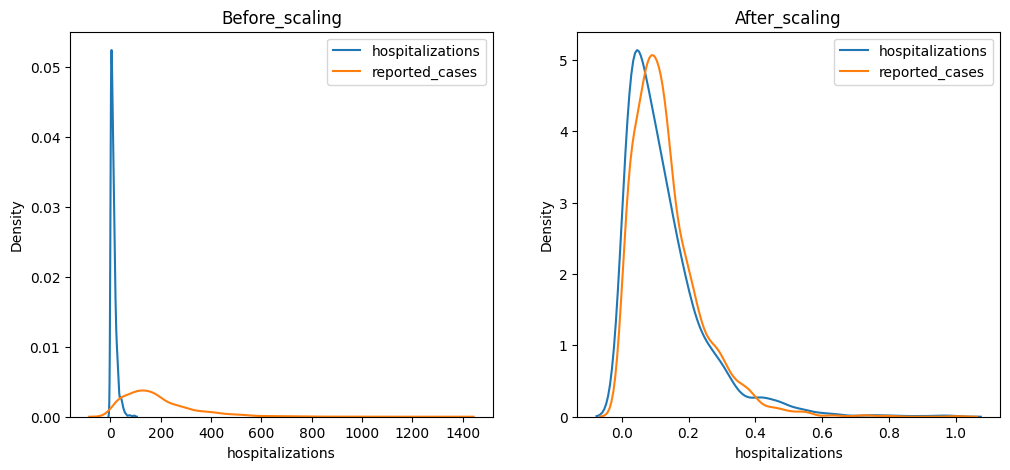

In [16]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.set_title("Before_scaling")
sns.kdeplot(X3_train['hospitalizations'], ax=ax1, label='hospitalizations')
sns.kdeplot(X3_train['reported_cases'], ax=ax1, label='reported_cases')
ax1.legend()

ax2.set_title("After_scaling")
sns.kdeplot(X3_train_scaled_df['hospitalizations'], ax=ax2, label='hospitalizations')
sns.kdeplot(X3_train_scaled_df['reported_cases'], ax=ax2, label='reported_cases')
ax2.legend()
plt.show()

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()
lr.fit(X3_train, Y3_train)
lr_scaled.fit(X3_train_scaled, Y3_train)

C:\Users\lands\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [19]:
Y3_pred=lr.predict(X3_test)
Y3_pred_scaled=lr_scaled.predict(X3_test_scaled)

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
print("Actual", accuracy_score(Y3_test, Y3_pred))
print("Scaled", accuracy_score(Y3_test, Y3_pred_scaled))

Actual 0.8444444444444444
Scaled 0.8412698412698413
